# Chapter 28 — Thesis and Capstone Projects
## *From topic selection to reproducible evidence*

This notebook does not choose or solve a thesis for you. It helps convert a broad idea into a project with explicit constraints, evidence, dependencies, and next actions.

## Setup
The notebook reads `project_candidates.csv`, the canonical editable project catalogue. No upload is required: if the file is not already present in the working directory (for example, when this notebook is opened directly from the Colab link on its own), the setup cell below creates it from a copy embedded in the notebook. If you already have the file -- for example because you downloaded the full chapter package -- your copy, including any edits, is used instead and is left untouched.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Publisher-friendly vector fonts for any saved PDF figures.
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

pd.set_option('display.max_colwidth', 90)

DATA = Path('project_candidates.csv')

# The archive and this notebook keep two copies of the same small teaching
# content on purpose: one for the full chapter package, one embedded here so
# the notebook is self-contained if opened alone (e.g. directly from the
# Colab link, with no other chapter files present). If the file is already
# present -- for example because the whole chapter package was downloaded --
# it is left untouched, so a reader's own edits to the catalogue survive a
# rerun.
BOOTSTRAP_CSV = 'id,topic,suggested_track,area,data,hardware_required,gpu_required,restricted_data,minimum_team_size,typical_duration_weeks,primary_metrics,novelty,feasibility,data_access,reproducibility,technical_depth,evidence_potential\nP1,Environmental sensor calibration and drift,Foundation,sensor/data,public or synthetic,0,0,0,1,8,"RMSE, bias, uncertainty",3,5,5,5,3,4\nP2,Battery-aware duty-cycle design for a remote node,Foundation,device/energy,synthetic workload,0,0,0,1,8,"lifetime, latency",3,5,5,5,3,3\nP3,Wi-Fi vs BLE for periodic telemetry,Foundation,communications,synthetic workload,0,0,0,1,8,"modelled energy, latency, throughput",2,5,5,5,3,3\nP4,MQTT QoS under intermittent connectivity,Foundation,protocols,synthetic/network trace,0,0,0,1,10,"delivery ratio, bytes, delay",3,5,5,5,4,4\nP5,Modbus-to-MQTT brownfield gateway,Capstone,industrial/gateway,synthetic registers,0,0,0,2,14,"latency, reliability, recoverability",4,4,4,4,5,5\nP6,LoRaWAN link-budget planning for campus sensing,Capstone,LPWAN,site assumptions,0,0,0,1,12,"coverage margin, airtime, modelled energy",3,4,4,5,4,4\nP7,Edge person detection under MCU resource limits,Research,edge AI,public image dataset,1,0,0,1,16,"accuracy, latency, memory, energy",5,3,5,4,5,5\nP8,Lightweight KAN intrusion detection for IoT,Research,security/AI,CICIDS2017 or newer benchmark,0,0,0,1,14,"F1, latency, model size",4,4,5,4,5,5\nP9,Merkle proofs for IoT data-integrity audit trails,Capstone,security/data,synthetic records,0,0,0,1,12,"proof size, build/verify time",4,5,5,5,4,4\nP10,Post-quantum algorithm benchmarking on constrained nodes,Research,security/crypto,standard test vectors,1,0,0,1,16,"time, RAM, flash, energy",5,3,5,4,5,5\nP11,Privacy-preserving biometric authentication for edge systems,Research,biometrics/privacy,licensed public datasets,0,1,1,1,16,"EER/FMR/FNMR, latency, template size",5,2,3,3,5,5\nP12,Resilient dual-link IoT architecture with failover,Capstone,architecture,fault scenarios,1,0,0,2,16,"availability, recovery time, cost",4,3,4,4,5,4\n'

if not DATA.exists():
    DATA.write_text(BOOTSTRAP_CSV, encoding='utf-8')
    print('project_candidates.csv was not found, so it was created from the',
          'notebook\'s embedded copy of the canonical catalogue.')
else:
    on_disk = DATA.read_text(encoding='utf-8')
    if on_disk != BOOTSTRAP_CSV:
        print('NOTE: project_candidates.csv on disk differs from the',
              'notebook\'s embedded fallback copy. The file on disk is',
              'authoritative for this run; this is expected and fine after',
              'a Challenge Task edits the catalogue.')

projects = pd.read_csv(DATA)
projects.head()

project_candidates.csv was not found, so it was created from the notebook's embedded copy of the canonical catalogue.


,id,topic,suggested_track,area,data,hardware_required,gpu_required,restricted_data,minimum_team_size,typical_duration_weeks,primary_metrics,novelty,feasibility,data_access,reproducibility,technical_depth,evidence_potential
0,P1,Environmental sensor calibration and drift,Foundation,sensor/data,public or synthetic,0,0,0,1,8,"RMSE, bias, uncertainty",3,5,5,5,3,4
1,P2,Battery-aware duty-cycle design for a remote node,Foundation,device/energy,synthetic workload,0,0,0,1,8,"lifetime, latency",3,5,5,5,3,3
2,P3,Wi-Fi vs BLE for periodic telemetry,Foundation,communications,synthetic workload,0,0,0,1,8,"modelled energy, latency, throughput",2,5,5,5,3,3
3,P4,MQTT QoS under intermittent connectivity,Foundation,protocols,synthetic/network trace,0,0,0,1,10,"delivery ratio, bytes, delay",3,5,5,5,4,4
4,P5,Modbus-to-MQTT brownfield gateway,Capstone,industrial/gateway,synthetic registers,0,0,0,2,14,"latency, reliability, recoverability",4,4,4,4,5,5


## Exercise 28.1 — Choose a project track, then apply hard constraints before ranking

A weighted score is meaningful only **after** the intended project form and infeasible options have been addressed. In this example the student is planning a **Foundation/course-project** scope: 12 weeks, one student, no dedicated IoT hardware or GPU, and only openly accessible or synthetic data.

The catalogue contains illustrative 1–5 planning scores:

- **1** — weak for the stated criterion;
- **3** — workable but with important limitations;
- **5** — strong for the stated criterion.

These are planning estimates, not measured scientific results. A real student should revise and justify them.


In [2]:
selected_track = 'Foundation'

constraints = {
    'max_weeks': 12,
    'team_size': 1,
    'hardware_available': False,
    'gpu_available': False,
    'restricted_data_allowed': False,
}

eligible = projects[projects['suggested_track'] == selected_track].copy()
eligible = eligible[eligible['typical_duration_weeks'] <= constraints['max_weeks']]
eligible = eligible[eligible['minimum_team_size'] <= constraints['team_size']]
if not constraints['hardware_available']:
    eligible = eligible[eligible['hardware_required'] == 0]
if not constraints['gpu_available']:
    eligible = eligible[eligible['gpu_required'] == 0]
if not constraints['restricted_data_allowed']:
    eligible = eligible[eligible['restricted_data'] == 0]

print(f"Selected track: {selected_track}")
print(f"Eligible projects after track + constraints: {len(eligible)} of {len(projects)}")
display(eligible[['id','topic','suggested_track','typical_duration_weeks']])

Selected track: Foundation
Eligible projects after track + constraints: 4 of 12


,id,topic,suggested_track,typical_duration_weeks
0,P1,Environmental sensor calibration and drift,Foundation,8
1,P2,Battery-aware duty-cycle design for a remote node,Foundation,8
2,P3,Wi-Fi vs BLE for periodic telemetry,Foundation,8
3,P4,MQTT QoS under intermittent connectivity,Foundation,10


In [3]:
weights = {
    'novelty': 0.10,
    'feasibility': 0.25,
    'data_access': 0.20,
    'reproducibility': 0.20,
    'technical_depth': 0.15,
    'evidence_potential': 0.10,
}
assert abs(sum(weights.values()) - 1.0) < 1e-12

eligible = eligible.copy()
eligible['planning_score'] = sum(eligible[k] * w for k, w in weights.items())
ranked = eligible.sort_values(['planning_score','feasibility'], ascending=False)
display(ranked[['id','topic','planning_score']].round(2))

,id,topic,planning_score
3,P4,MQTT QoS under intermittent connectivity,4.55
0,P1,Environmental sensor calibration and drift,4.40
1,P2,Battery-aware duty-cycle design for a remote node,4.30
2,P3,Wi-Fi vs BLE for periodic telemetry,4.20


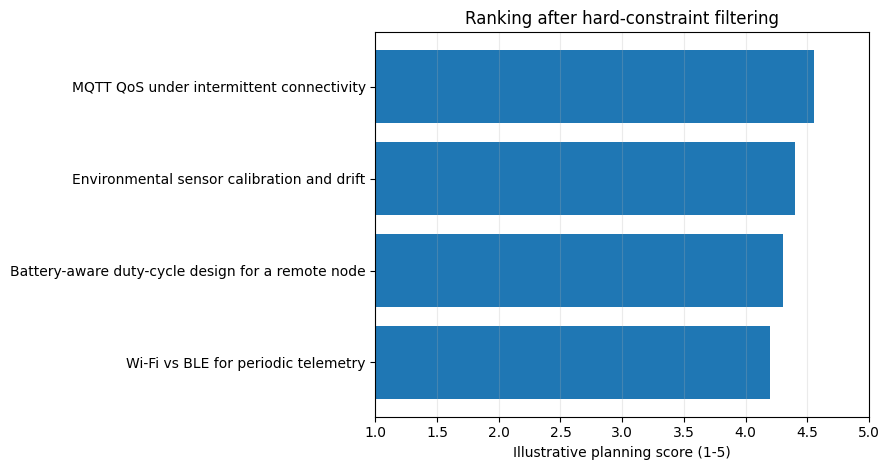

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = ranked.sort_values('planning_score')
ax.barh(plot_df['topic'], plot_df['planning_score'])
ax.set_xlim(1, 5)
ax.set_xlabel('Illustrative planning score (1-5)')
ax.set_title('Ranking after hard-constraint filtering')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation
The important result is not the identity of the top bar. Choosing the project track removes options whose expected scope does not fit the intended form; the hard filter then removes projects that do not fit the stated resources. The weighted stage makes preferences explicit only among the remaining candidates. Change the track, constraints, or weights and explain why the candidate set or ranking changes.


## Exercise 28.2 — Convert claims into an experimental budget

Every claim multiplies the experimental workload. The table below uses a simple accounting model:

`runs = variants × conditions × repetitions × datasets`

It also estimates compute time and result storage so that scope problems are visible before implementation. The repetition counts are planning placeholders; a real study should justify them from expected variability, required precision, power/sample-size reasoning where appropriate, prior evidence, or an accepted protocol.

In [5]:
evidence = pd.DataFrame([
    ('Task quality improves', 2, 1, 5, 1, 20, 50),
    ('Efficiency improves', 2, 2, 10, 1, 10, 20),
    ('Robustness holds', 2, 3, 5, 1, 15, 60),
    ('Generalisation holds', 2, 1, 5, 2, 20, 100),
], columns=['claim','variants','conditions','repetitions','datasets','minutes_per_run','MB_per_run'])

evidence['total_runs'] = evidence['variants'] * evidence['conditions'] * evidence['repetitions'] * evidence['datasets']
evidence['compute_hours'] = evidence['total_runs'] * evidence['minutes_per_run'] / 60
evidence['storage_GB'] = evidence['total_runs'] * evidence['MB_per_run'] / 1000
display(evidence.round({'compute_hours':2,'storage_GB':2}))
print('Total runs:', int(evidence['total_runs'].sum()))
print('Estimated compute hours:', round(float(evidence['compute_hours'].sum()), 1))
print('Estimated result storage (GB):', round(float(evidence['storage_GB'].sum()), 1))

,claim,variants,conditions,repetitions,datasets,minutes_per_run,MB_per_run,total_runs,compute_hours,storage_GB
0,Task quality improves,2,1,5,1,20,50,10,3.33,0.5
1,Efficiency improves,2,2,10,1,10,20,40,6.67,0.8
2,Robustness holds,2,3,5,1,15,60,30,7.50,1.8
3,Generalisation holds,2,1,5,2,20,100,20,6.67,2.0


Total runs: 100
Estimated compute hours: 24.2
Estimated result storage (GB): 5.1


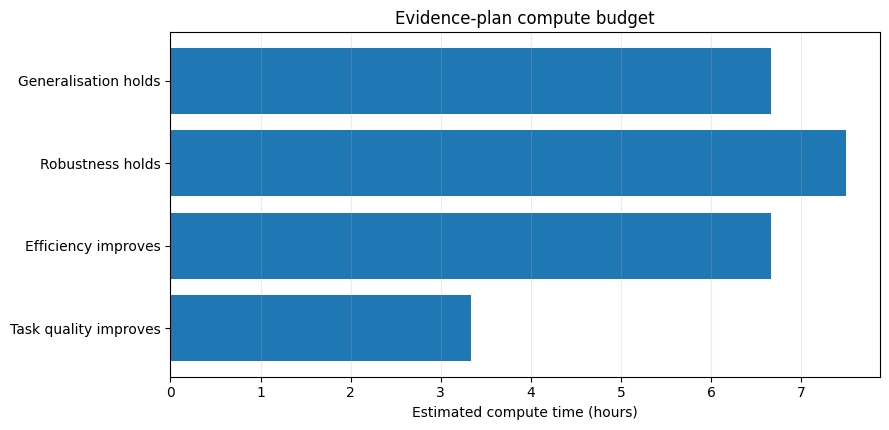

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(evidence['claim'], evidence['compute_hours'])
ax.set_xlabel('Estimated compute time (hours)')
ax.set_title('Evidence-plan compute budget')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation
The example produces 100 planned runs and a non-trivial compute/storage budget. If that exceeds the available time, reduce a claim, variant set, condition set, or repetition count **before** coding. Do not silently reduce evaluation after seeing the results.

## Exercise 28.3 — Build a dependency-aware milestone plan

The schedule below uses weeks numbered from **1**, matching the chapter text. Each task starts only after its dependency finishes.

In [7]:
tasks = pd.DataFrame([
    ('M1','Reproduce baseline',2,''),
    ('M2','Define experiment',2,'M1'),
    ('M3','Implement contribution',4,'M2'),
    ('M4','Run evaluation',3,'M3'),
    ('M5','Analyse limitations',2,'M4'),
    ('M6','Write and package artifact',3,'M5'),
], columns=['id','task','duration','depends_on'])

def schedule_tasks(frame, extra_duration=None):
    extra_duration = extra_duration or {}
    result = []
    finish = {}
    for row in frame.itertuples(index=False):
        start = 1 if not row.depends_on else finish[row.depends_on] + 1
        effective_duration = int(row.duration) + int(extra_duration.get(row.id, 0))
        end = start + effective_duration - 1
        finish[row.id] = end
        result.append((row.id, row.task, start, end, effective_duration, row.depends_on))
    return pd.DataFrame(result, columns=['id','task','start_week','end_week','effective_duration','depends_on'])

baseline_schedule = schedule_tasks(tasks)
overrun_schedule = schedule_tasks(tasks, {'M1': 3})
display(baseline_schedule)
print('Baseline completion week:', int(baseline_schedule['end_week'].max()))
print('With a 3-week M1 overrun:', int(overrun_schedule['end_week'].max()))

,id,task,start_week,end_week,effective_duration,depends_on
0,M1,Reproduce baseline,1,2,2,
1,M2,Define experiment,3,4,2,M1
2,M3,Implement contribution,5,8,4,M2
3,M4,Run evaluation,9,11,3,M3
4,M5,Analyse limitations,12,13,2,M4
5,M6,Write and package artifact,14,16,3,M5


Baseline completion week: 16
With a 3-week M1 overrun: 19


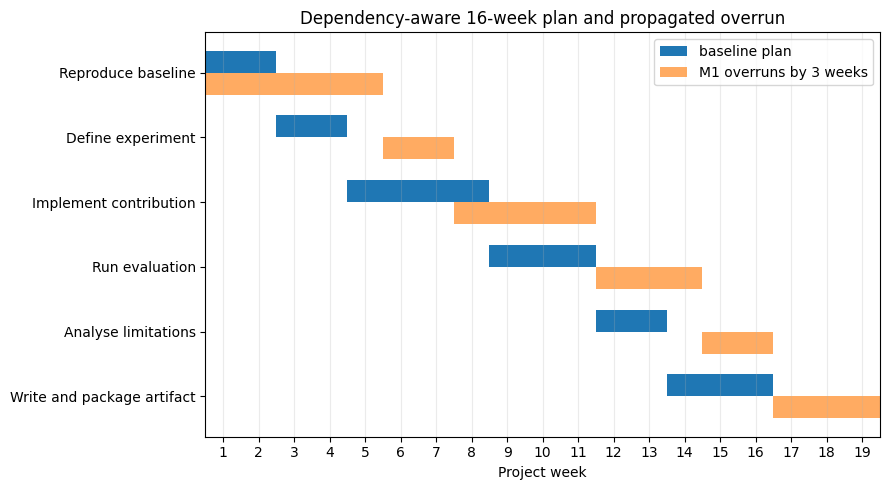

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.0))
y = np.arange(len(tasks))
h = 0.34
ax.barh(y-h/2, baseline_schedule['effective_duration'], left=baseline_schedule['start_week']-0.5, height=h, label='baseline plan')
ax.barh(y+h/2, overrun_schedule['effective_duration'], left=overrun_schedule['start_week']-0.5, height=h, label='M1 overruns by 3 weeks', alpha=0.65)
ax.set_yticks(y, tasks['task'])
ax.invert_yaxis()
ax.set_xlabel('Project week')
ax.set_xticks(range(1, 20))
ax.set_xlim(0.5, 19.5)
ax.set_title('Dependency-aware 16-week plan and propagated overrun')
ax.grid(axis='x', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation
The baseline schedule finishes in week 16. A three-week overrun in M1 propagates through every dependent task and moves completion to week 19. The student must therefore add contingency time, parallelise only genuinely independent tasks, or reduce scope before the evaluation phase is compressed.

## Exercise 28.4 — Research-extension gap analysis

Use the following diagnostic rubric consistently:

- **0** absent;
- **1** recognised but not addressed;
- **2** partial;
- **3** adequate for the current thesis/capstone claim;
- **4** strong;
- **5** independently verifiable for the stated evidence dimension.

The score is a planning aid. It does not predict publication acceptance; publication requirements remain venue- and claim-specific.

In [9]:
readiness = pd.DataFrame([
    ('Clear research question', 5, 'freeze wording and keep scope stable'),
    ('Baseline reproduced', 5, 'archive environment and baseline result'),
    ('Novel contribution', 3, 'strengthen literature positioning and isolate the new element'),
    ('Evaluation depth', 3, 'add a second baseline or a justified stress condition'),
    ('Uncertainty and statistics', 2, 'plan repeated runs and uncertainty reporting'),
    ('Code reproducibility', 4, 'test clean installation and one-command result generation'),
    ('Data licensing', 5, 'record lawful acquisition and redistribution limits'),
    ('Limitations', 2, 'state boundary conditions and known failure cases explicitly'),
], columns=['dimension','score','next_action'])

readiness_sorted = readiness.sort_values(['score','dimension'])
display(readiness_sorted)
print('Three highest-priority gaps:')
display(readiness_sorted.head(3)[['dimension','score','next_action']])

,dimension,score,next_action
7,Limitations,2,state boundary conditions and known failure cases explicitly
4,Uncertainty and statistics,2,plan repeated runs and uncertainty reporting
3,Evaluation depth,3,add a second baseline or a justified stress condition
2,Novel contribution,3,strengthen literature positioning and isolate the new element
5,Code reproducibility,4,test clean installation and one-command result generation
1,Baseline reproduced,5,archive environment and baseline result
0,Clear research question,5,freeze wording and keep scope stable
6,Data licensing,5,record lawful acquisition and redistribution limits


Three highest-priority gaps:


,dimension,score,next_action
7,Limitations,2,state boundary conditions and known failure cases explicitly
4,Uncertainty and statistics,2,plan repeated runs and uncertainty reporting
3,Evaluation depth,3,add a second baseline or a justified stress condition


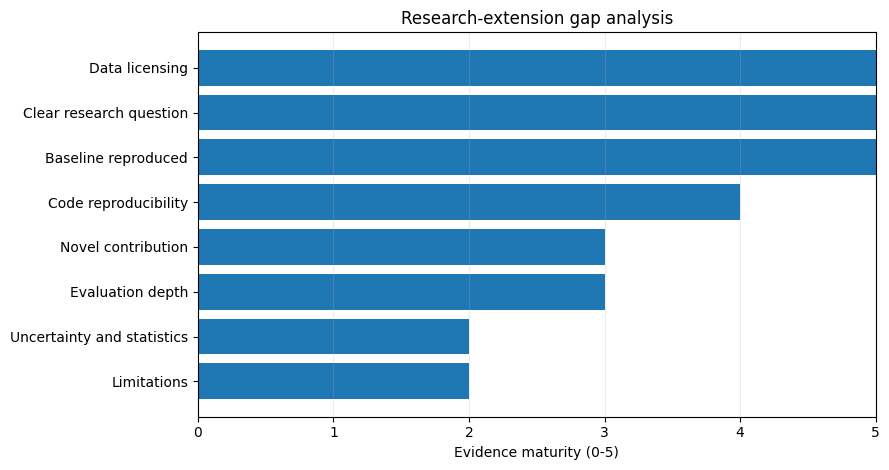

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(readiness_sorted['dimension'], readiness_sorted['score'])
ax.set_xlim(0,5)
ax.set_xlabel('Evidence maturity (0-5)')
ax.set_title('Research-extension gap analysis')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation
The weakest dimensions become the next actions. In this example the project should first strengthen uncertainty reporting and limitations, then address evaluation depth with an additional justified baseline or stress condition. A thesis can be complete even when a publication gap remains.

## Practice summary
A defensible project has a scoped question, explicit hard constraints, a reproducible baseline, measurable evidence, a feasible dependency-aware schedule, and a clear limitations statement. Publication becomes a possible continuation of good project work, not a mandatory final milestone.